# Understanding the Key Drivers of Electric Vehicle Adoption

## Project Objective

The objective of this project is to identify the key factors influencing electric vehicle (EV) adoption among consumers.

Using a dataset containing 50,000 consumer records, this analysis explores how demographic characteristics, charging infrastructure, environmental awareness, technology affinity, and psychological factors affect EV adoption likelihood.

The project combines exploratory data analysis (EDA), statistical analysis, machine learning, and data visualization to uncover meaningful insights regarding EV adoption behavior.

In [7]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\srinj\OneDrive\Documents\EV_Adoption_Project\data\ev_dataset.csv"
)

df.head()

,age,annual_income,education_level,city_type,daily_commute_km,weekly_travel_distance_km,current_vehicle_type,vehicle_age_years,fuel_expense_per_month,charging_station_accessibility,...,environmental_awareness_score,government_incentive_awareness,technology_affinity_score,range_anxiety_score,battery_replacement_concern,ev_knowledge_score,previous_ev_experience,ev_adoption_likelihood,monthly_energy_consumption_kwh,monthly_charging_cost
0,56,23019,High School,Suburban,39.8,205.7,Hatchback,6.1,317.1,3.9,...,8.3,6.4,5.2,4.6,3.5,6.9,0,High,199.8,28.5
1,46,26440,High School,Suburban,34.6,218.4,Sedan,4.4,290.0,4.5,...,7.8,10.0,5.7,5.5,7.4,6.9,1,High,139.8,22.9
2,46,57167,PhD,Suburban,30.5,177.7,Sedan,0.4,201.4,6.3,...,7.6,6.4,7.8,5.3,6.2,6.8,0,High,158.0,38.5
3,23,15841,Master,Suburban,44.6,325.9,SUV,0.0,407.3,5.2,...,6.2,5.6,5.1,7.9,5.7,7.2,0,Low,207.0,45.0
4,50,51571,Master,Urban,52.4,281.0,SUV,5.2,458.4,4.3,...,9.7,9.9,8.2,2.6,4.7,8.1,0,High,195.6,43.9


In [8]:
df.shape

(50000, 23)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             50000 non-null  int64  
 1   annual_income                   50000 non-null  int64  
 2   education_level                 49500 non-null  object 
 3   city_type                       50000 non-null  object 
 4   daily_commute_km                50000 non-null  float64
 5   weekly_travel_distance_km       50000 non-null  float64
 6   current_vehicle_type            50000 non-null  object 
 7   vehicle_age_years               50000 non-null  float64
 8   fuel_expense_per_month          50000 non-null  float64
 9   charging_station_accessibility  49500 non-null  float64
 10  nearest_charging_station_km     50000 non-null  float64
 11  home_charging_available         50000 non-null  int64  
 12  electricity_cost_per_kwh        

In [10]:
df.isnull().sum()

age                                 0
annual_income                       0
education_level                   500
city_type                           0
daily_commute_km                    0
weekly_travel_distance_km           0
current_vehicle_type                0
vehicle_age_years                   0
fuel_expense_per_month              0
charging_station_accessibility    500
nearest_charging_station_km         0
home_charging_available             0
electricity_cost_per_kwh            0
environmental_awareness_score       0
government_incentive_awareness      0
technology_affinity_score           0
range_anxiety_score                 0
battery_replacement_concern         0
ev_knowledge_score                500
previous_ev_experience              0
ev_adoption_likelihood              0
monthly_energy_consumption_kwh      0
monthly_charging_cost               0
dtype: int64

In [11]:
df["ev_adoption_likelihood"].describe()

count     50000
unique        3
top        High
freq      29670
Name: ev_adoption_likelihood, dtype: object

In [12]:
df["ev_adoption_likelihood"].unique()[:20]

array(['High', 'Low', 'Medium'], dtype=object)

# Dataset Overview

The dataset contains:
- 50,000 records
- 23 variables

The variables include:
- Demographic factors
- Financial factors
- Charging infrastructure
- Environmental attitudes
- Technology adoption behavior
- EV-related perceptions

# Data Cleaning

The dataset was checked for missing values and inconsistencies.

A small number of missing values were identified in:

- Education Level
- Charging Station Accessibility
- EV Knowledge Score

Since the proportion of missing values was low, they were handled using appropriate imputation techniques:
- Mode for categorical variables
- Median for numerical variables

In [13]:
# Missing Values
df.isnull().sum()

age                                 0
annual_income                       0
education_level                   500
city_type                           0
daily_commute_km                    0
weekly_travel_distance_km           0
current_vehicle_type                0
vehicle_age_years                   0
fuel_expense_per_month              0
charging_station_accessibility    500
nearest_charging_station_km         0
home_charging_available             0
electricity_cost_per_kwh            0
environmental_awareness_score       0
government_incentive_awareness      0
technology_affinity_score           0
range_anxiety_score                 0
battery_replacement_concern         0
ev_knowledge_score                500
previous_ev_experience              0
ev_adoption_likelihood              0
monthly_energy_consumption_kwh      0
monthly_charging_cost               0
dtype: int64

In [14]:
df["education_level"] = df["education_level"].fillna(
    df["education_level"].mode()[0]
)

df["charging_station_accessibility"] = df[
    "charging_station_accessibility"
].fillna(
    df["charging_station_accessibility"].median()
)

df["ev_knowledge_score"] = df[
    "ev_knowledge_score"
].fillna(
    df["ev_knowledge_score"].median()
)

In [15]:
df.isnull().sum()

age                               0
annual_income                     0
education_level                   0
city_type                         0
daily_commute_km                  0
weekly_travel_distance_km         0
current_vehicle_type              0
vehicle_age_years                 0
fuel_expense_per_month            0
charging_station_accessibility    0
nearest_charging_station_km       0
home_charging_available           0
electricity_cost_per_kwh          0
environmental_awareness_score     0
government_incentive_awareness    0
technology_affinity_score         0
range_anxiety_score               0
battery_replacement_concern       0
ev_knowledge_score                0
previous_ev_experience            0
ev_adoption_likelihood            0
monthly_energy_consumption_kwh    0
monthly_charging_cost             0
dtype: int64

# Target Variable Analysis

The target variable, EV Adoption Likelihood, categorizes consumers into:

- Low
- Medium
- High

Understanding the distribution of the target variable is important before building predictive models.

In [16]:
df["ev_adoption_likelihood"].value_counts()

ev_adoption_likelihood
High      29670
Medium    12078
Low        8252
Name: count, dtype: int64

In [17]:
df["ev_adoption_likelihood"].value_counts(normalize=True)*100

ev_adoption_likelihood
High      59.340
Medium    24.156
Low       16.504
Name: proportion, dtype: float64

### Observation

The dataset contains a larger proportion of consumers with High EV adoption likelihood compared to Medium and Low categories.

This indicates that the dataset is moderately imbalanced and should be considered when evaluating model performance.

# Exploratory Data Analysis (EDA)

EDA was performed to investigate how different consumer characteristics vary across EV adoption groups.

The objective is to identify patterns and relationships that may explain adoption behavior.

In [18]:
df.groupby("ev_adoption_likelihood")[
    "annual_income"
].mean()

ev_adoption_likelihood
High      52219.834007
Low       29402.017693
Medium    35072.490810
Name: annual_income, dtype: float64

In [19]:
df.groupby("ev_adoption_likelihood")[
    "environmental_awareness_score"
].mean()

ev_adoption_likelihood
High      7.862632
Low       4.467523
Medium    5.915085
Name: environmental_awareness_score, dtype: float64

In [20]:
df.groupby("ev_adoption_likelihood")[
    "technology_affinity_score"
].mean()

ev_adoption_likelihood
High      7.812733
Low       4.413039
Medium    5.619763
Name: technology_affinity_score, dtype: float64

In [21]:
df.groupby("ev_adoption_likelihood")[
    "range_anxiety_score"
].mean()

ev_adoption_likelihood
High      4.136363
Low       7.757477
Medium    6.430013
Name: range_anxiety_score, dtype: float64

In [22]:
df.groupby("ev_adoption_likelihood")["ev_knowledge_score"].mean()

ev_adoption_likelihood
High      7.860880
Low       4.291372
Medium    5.734484
Name: ev_knowledge_score, dtype: float64

In [23]:
df.groupby("ev_adoption_likelihood")["government_incentive_awareness"].mean()

ev_adoption_likelihood
High      6.154142
Low       5.503514
Medium    5.877637
Name: government_incentive_awareness, dtype: float64

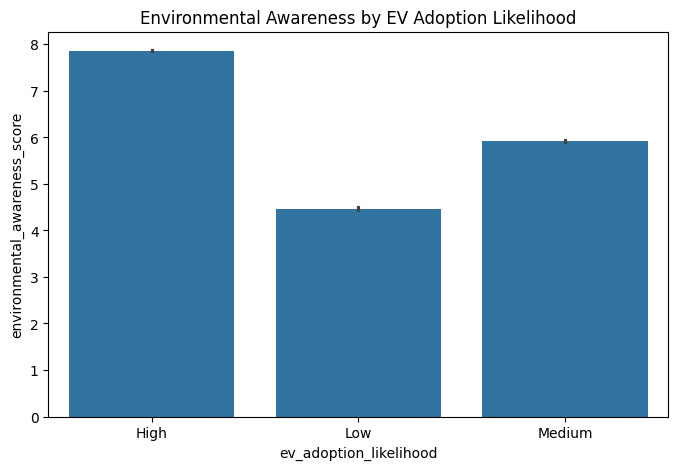

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="ev_adoption_likelihood",
    y="environmental_awareness_score"
)

plt.title("Environmental Awareness by EV Adoption Likelihood")
plt.show()

### Environmental Awareness and EV Adoption

Consumers with higher environmental awareness scores exhibit substantially higher EV adoption likelihood.

This suggests that environmental consciousness may play an important role in encouraging EV adoption.

In [25]:
mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

df["adoption_score"] = df["ev_adoption_likelihood"].map(mapping)

In [26]:
df[["ev_adoption_likelihood", "adoption_score"]].head()

,ev_adoption_likelihood,adoption_score
0,High,2
1,High,2
2,High,2
3,Low,0
4,High,2


# Correlation Analysis

To quantify relationships between variables, EV adoption likelihood was converted into a numerical adoption score.

Correlation analysis was then used to identify variables that are most strongly associated with EV adoption.

In [27]:
corr = df.corr(numeric_only=True)

corr["adoption_score"].sort_values(ascending=False)

adoption_score                    1.000000
ev_knowledge_score                0.723015
environmental_awareness_score     0.688101
technology_affinity_score         0.681269
annual_income                     0.361330
charging_station_accessibility    0.178061
government_incentive_awareness    0.122762
home_charging_available           0.095015
previous_ev_experience            0.083034
daily_commute_km                  0.003845
monthly_charging_cost             0.003834
weekly_travel_distance_km         0.003125
fuel_expense_per_month            0.002780
monthly_energy_consumption_kwh    0.002548
age                               0.000964
electricity_cost_per_kwh          0.000469
vehicle_age_years                -0.006091
nearest_charging_station_km      -0.109325
battery_replacement_concern      -0.149160
range_anxiety_score              -0.698493
Name: adoption_score, dtype: float64

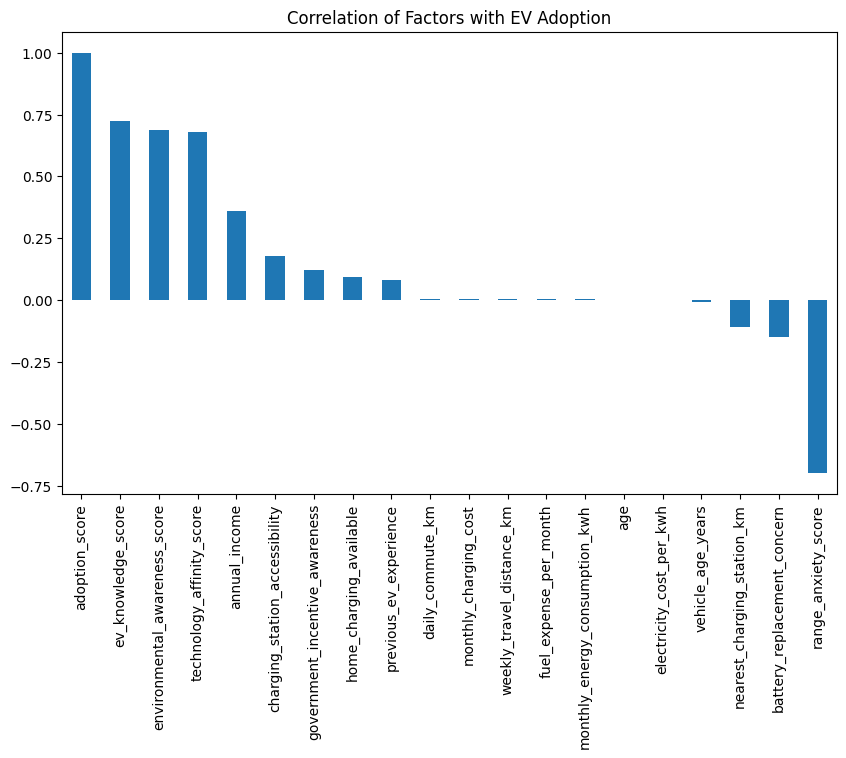

In [28]:
corr_target = corr["adoption_score"].sort_values(ascending=False)

corr_target.plot(kind="bar", figsize=(10,6))

plt.title("Correlation of Factors with EV Adoption")
plt.show()

### Correlation Findings

Several variables demonstrated strong relationships with EV adoption.

The strongest positive relationships were observed for:
- Environmental Awareness
- Technology Affinity
- EV Knowledge

Strong negative relationships were observed for:
- Range Anxiety
- Battery Replacement Concerns

These findings indicate that consumer perceptions and knowledge may significantly influence EV adoption decisions.

## Home Charging Infrastructure

Home charging availability is expected to influence EV adoption because it directly affects convenience and charging accessibility.

In [29]:
pd.crosstab(
    df["home_charging_available"],
    df["ev_adoption_likelihood"],
    normalize="index"
) * 100

ev_adoption_likelihood,High,Low,Medium
home_charging_available,,,
0,53.551850,20.528780,25.919370
1,62.459985,14.334524,23.205491


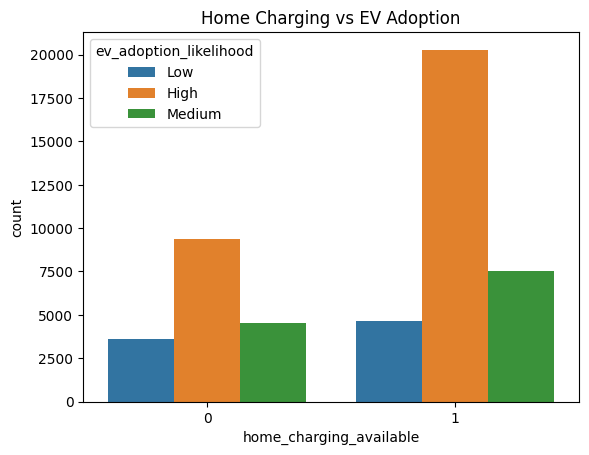

In [30]:
sns.countplot(
    data=df,
    x="home_charging_available",
    hue="ev_adoption_likelihood"
)

plt.title("Home Charging vs EV Adoption")
plt.show()

In [31]:
df.groupby("ev_adoption_likelihood")[
    "range_anxiety_score"
].mean()

ev_adoption_likelihood
High      4.136363
Low       7.757477
Medium    6.430013
Name: range_anxiety_score, dtype: float64

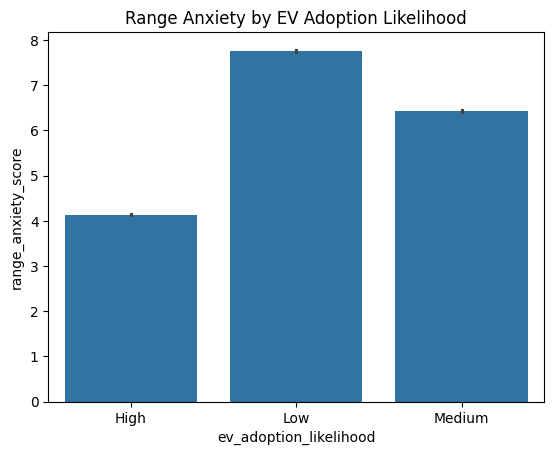

In [32]:
sns.barplot(
    data=df,
    x="ev_adoption_likelihood",
    y="range_anxiety_score"
)

plt.title("Range Anxiety by EV Adoption Likelihood")
plt.show()

### Range Anxiety and EV Adoption

Range anxiety represents concerns regarding battery range and charging availability.

Consumers with higher range anxiety tend to show lower EV adoption likelihood, suggesting that charging confidence remains a major barrier to EV adoption.

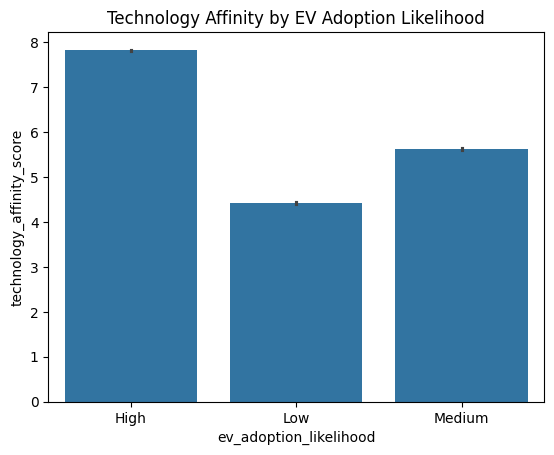

In [33]:
sns.barplot(
    data=df,
    x="ev_adoption_likelihood",
    y="technology_affinity_score"
)

plt.title("Technology Affinity by EV Adoption Likelihood")
plt.show()

### Technology Affinity and EV Adoption

Technology affinity increases consistently from Low to High adoption groups.

Consumers who are more comfortable adopting new technologies appear more willing to adopt electric vehicles.

In [34]:
df["ev_adoption_likelihood"].value_counts()

ev_adoption_likelihood
High      29670
Medium    12078
Low        8252
Name: count, dtype: int64

In [35]:
df["ev_adoption_likelihood"].value_counts(normalize=True) * 100

ev_adoption_likelihood
High      59.340
Medium    24.156
Low       16.504
Name: proportion, dtype: float64

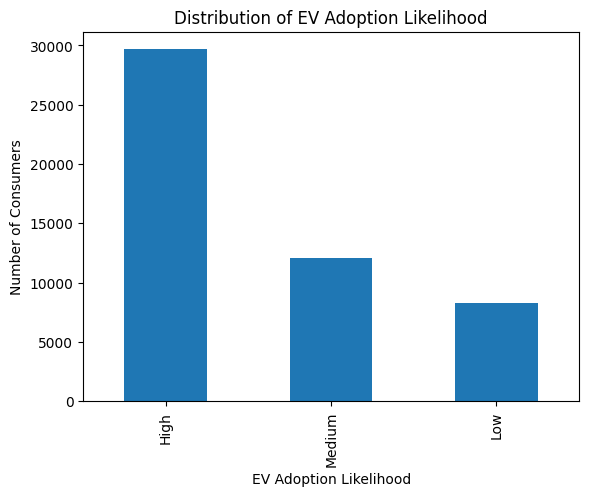

In [36]:
import matplotlib.pyplot as plt

df["ev_adoption_likelihood"].value_counts().plot(
    kind="bar"
)

plt.title("Distribution of EV Adoption Likelihood")
plt.xlabel("EV Adoption Likelihood")
plt.ylabel("Number of Consumers")

plt.show()

In [37]:
df_model = df.copy()

In [38]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df_model.select_dtypes(include="object").columns:
    df_model[col] = le.fit_transform(df_model[col])

In [39]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             50000 non-null  int64  
 1   annual_income                   50000 non-null  int64  
 2   education_level                 50000 non-null  int64  
 3   city_type                       50000 non-null  int64  
 4   daily_commute_km                50000 non-null  float64
 5   weekly_travel_distance_km       50000 non-null  float64
 6   current_vehicle_type            50000 non-null  int64  
 7   vehicle_age_years               50000 non-null  float64
 8   fuel_expense_per_month          50000 non-null  float64
 9   charging_station_accessibility  50000 non-null  float64
 10  nearest_charging_station_km     50000 non-null  float64
 11  home_charging_available         50000 non-null  int64  
 12  electricity_cost_per_kwh        

In [40]:
X = df_model.drop(
    ["ev_adoption_likelihood", "adoption_score"],
    axis=1
)

y = df_model["adoption_score"]

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Machine Learning Model

A Random Forest Classifier was developed to predict EV adoption likelihood.

Random Forest was selected because:
- It handles mixed data effectively
- It captures complex relationships
- It provides feature importance scores

These feature importance scores help identify the most influential factors affecting EV adoption.

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [43]:
from sklearn.metrics import accuracy_score

pred = rf.predict(X_test)

accuracy_score(y_test, pred)

0.8422

In [44]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
16,range_anxiety_score,0.158426
18,ev_knowledge_score,0.154945
13,environmental_awareness_score,0.127758
15,technology_affinity_score,0.125760
9,charging_station_accessibility,0.051820
17,battery_replacement_concern,0.047730
1,annual_income,0.045023
14,government_incentive_awareness,0.040975
10,nearest_charging_station_km,0.028603
7,vehicle_age_years,0.023737


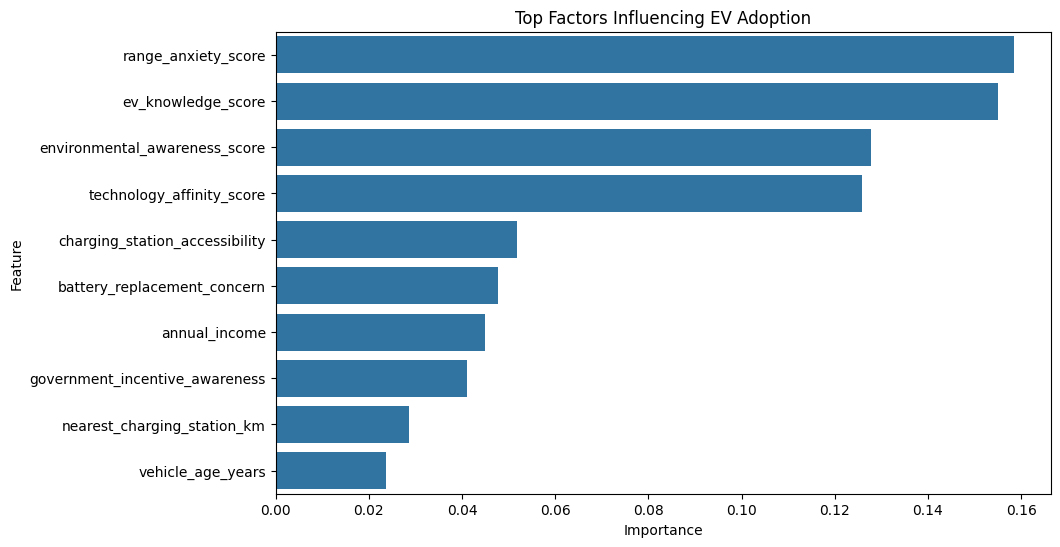

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top Factors Influencing EV Adoption")
plt.show()

### Interpretation

The Random Forest model identified range anxiety, EV knowledge, environmental awareness, and technology affinity as the strongest predictors of EV adoption.

This suggests that psychological and informational factors may have a greater impact on EV adoption decisions than purely economic factors such as annual income.

## Correlation Heatmap

The heatmap provides a visual representation of relationships among all numerical variables in the dataset.

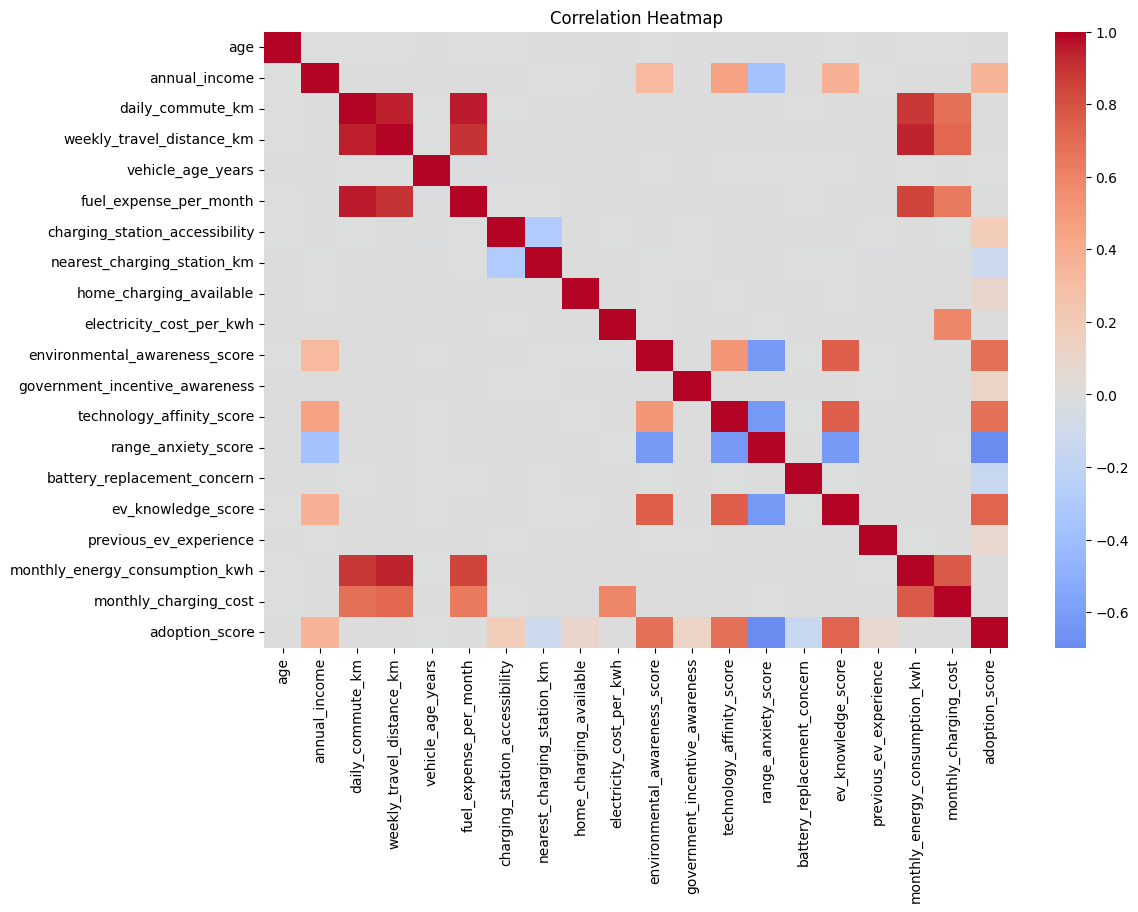

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

In [47]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)

print(cm)

[[1203  423    6]
 [ 267 1671  506]
 [   4  372 5548]]


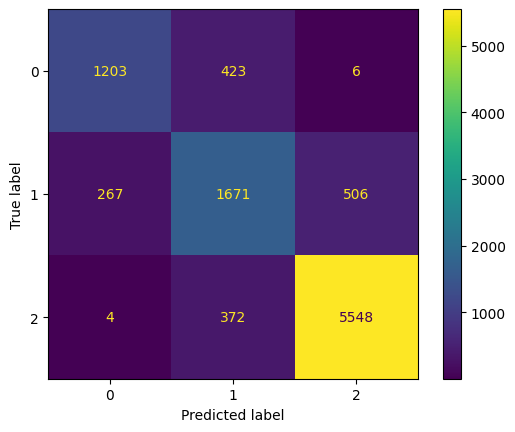

In [48]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(cm).plot()
plt.show()

In [49]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.82      0.74      0.77      1632
           1       0.68      0.68      0.68      2444
           2       0.92      0.94      0.93      5924

    accuracy                           0.84     10000
   macro avg       0.80      0.79      0.79     10000
weighted avg       0.84      0.84      0.84     10000



# Model Evaluation

The confusion matrix and classification report were used to assess the model's predictive performance.

The results indicate that the model performs well across the three adoption categories and demonstrates strong predictive capability.

## Managerial Implications

The results suggest that policymakers and EV manufacturers should focus on:

- Reducing range anxiety
- Increasing EV awareness campaigns
- Educating consumers about EV technology
- Expanding charging infrastructure

These interventions may increase consumer willingness to adopt electric vehicles.